In [1]:
!pip install openai numpy pandas

In [2]:
import numpy as np
import pandas as pd
from openai import OpenAI

In [3]:
from getpass import getpass

OPENROUTER_API_KEY = getpass("Digite sua chave do OpenRouter: ")

Digite sua chave do OpenRouter: ··········


In [4]:
from openai import OpenAI

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY
)

In [5]:
MODELO_EMBEDDING = "nvidia/llama-nemotron-embed-vl-1b-v2:free"

In [8]:
def get_embedding(texto):
    resposta = client.embeddings.create(
        model=MODELO_EMBEDDING,
        input=texto,
        encoding_format="float"
    )

    return resposta.data[0].embedding

In [9]:
embedding_gato = get_embedding("gato")

print(embedding_gato[:10])
print("Dimensão:", len(embedding_gato))

[-0.060333251953125, 0.0028781890869140625, 0.01122283935546875, 0.0084075927734375, -0.018402099609375, 0.022216796875, -0.0167999267578125, -0.038238525390625, 0.0021190643310546875, 0.009674072265625]
Dimensão: 2048


In [10]:
palavras = [
    "gato",
    "felino",
    "cachorro",
    "carro",
    "caminhão",
    "moto",
    "banana",
    "maçã",
    "goiaba"
]

embeddings = {}

for palavra in palavras:
    print(f"Gerando embedding: {palavra}")

    vetor = get_embedding(palavra)

    embeddings[palavra] = np.array(
        vetor,
        dtype=np.float32
    )

print("\nEmbeddings gerados com sucesso!")

Gerando embedding: gato
Gerando embedding: felino
Gerando embedding: cachorro
Gerando embedding: carro
Gerando embedding: caminhão
Gerando embedding: moto
Gerando embedding: banana
Gerando embedding: maçã
Gerando embedding: goiaba

Embeddings gerados com sucesso!


In [11]:
print("Dimensão de gato:", len(embeddings["gato"]))
print("Dimensão de cachorro:", len(embeddings["cachorro"]))
print("Dimensão de carro:", len(embeddings["carro"]))

Dimensão de gato: 2048
Dimensão de cachorro: 2048
Dimensão de carro: 2048


In [12]:
def distancia_euclidiana(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """
    Calcula a Distância Euclidiana entre dois vetores.
    Quanto MENOR o resultado, mais próximos são os vetores.
    """
    return float(np.linalg.norm(vec1 - vec2))


def similaridade_cosseno(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """
    Calcula a Similaridade de Cosseno entre dois vetores.
    Quanto MAIOR o resultado, maior a similaridade.
    """
    norm_v1 = np.linalg.norm(vec1)
    norm_v2 = np.linalg.norm(vec2)

    if norm_v1 == 0 or norm_v2 == 0:
        return 0.0

    return float(
        np.dot(vec1, vec2) / (norm_v1 * norm_v2)
    )


def distancia_cosseno(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """
    Calcula a Distância de Cosseno.
    Quanto MENOR o resultado, mais semelhantes são os vetores.
    """
    return float(
        1.0 - similaridade_cosseno(vec1, vec2)
    )

In [13]:
comparacoes = [
    ("gato", "felino"),
    ("gato", "cachorro"),
    ("gato", "carro"),
    ("carro", "caminhão"),
    ("carro", "moto"),
    ("banana", "maçã"),
    ("banana", "goiaba"),
    ("banana", "carro")
]

resultados = []

for palavra1, palavra2 in comparacoes:

    vec1 = embeddings[palavra1]
    vec2 = embeddings[palavra2]

    resultados.append({
        "Palavra 1": palavra1,
        "Palavra 2": palavra2,
        "Distância Euclidiana": round(
            distancia_euclidiana(vec1, vec2), 4
        ),
        "Similaridade Cosseno": round(
            similaridade_cosseno(vec1, vec2), 4
        ),
        "Distância Cosseno": round(
            distancia_cosseno(vec1, vec2), 4
        )
    })

df_resultados = pd.DataFrame(resultados)

df_resultados

,Palavra 1,Palavra 2,Distância Euclidiana,Similaridade Cosseno,Distância Cosseno
0,gato,felino,1.0940,0.4018,0.5982
1,gato,cachorro,1.0384,0.4609,0.5391
2,gato,carro,1.1743,0.3106,0.6894
3,carro,caminhão,0.9705,0.5291,0.4709
4,carro,moto,0.9737,0.5259,0.4741
5,banana,maçã,1.1030,0.3917,0.6083
6,banana,goiaba,1.1218,0.3708,0.6292
7,banana,carro,1.1959,0.2848,0.7152


In [14]:
frase_ancora = "O cachorro correu no parque e brincou com a bola."

frases_comparacao = [
    (
        "Similar (mesmo sentido, palavras diferentes)",
        "Um cão estava correndo no jardim e brincando com seu brinquedo."
    ),
    (
        "Relacionado (mesmo contexto de animais)",
        "O gato dormiu na almofada da sala durante toda a tarde."
    ),
    (
        "Diferente (outro domínio - economia)",
        "A taxa de juros do banco central subiu dois pontos percentuais."
    ),
    (
        "Oposto/Negação",
        "Nenhum animal esteve no parque e o cão permaneceu preso em casa."
    )
]

In [15]:
vec_ancora = np.array(
    get_embedding(frase_ancora),
    dtype=np.float32
)

resultados_frases = []

for categoria, frase in frases_comparacao:

    vec = np.array(
        get_embedding(frase),
        dtype=np.float32
    )

    resultados_frases.append({
        "Categoria": categoria,
        "Dist. Euclidiana": round(
            distancia_euclidiana(vec_ancora, vec), 4
        ),
        "Similaridade Cosseno": round(
            similaridade_cosseno(vec_ancora, vec), 4
        ),
        "Distância Cosseno": round(
            distancia_cosseno(vec_ancora, vec), 4
        )
    })

df_frases = pd.DataFrame(resultados_frases)

df_frases

,Categoria,Dist. Euclidiana,Similaridade Cosseno,Distância Cosseno
0,"Similar (mesmo sentido, palavras diferentes)",0.8053,0.6757,0.3243
1,Relacionado (mesmo contexto de animais),1.1765,0.3074,0.6926
2,Diferente (outro domínio - economia),1.3469,0.0927,0.9073
3,Oposto/Negação,1.0073,0.4926,0.5074


In [16]:
from google.colab import files

arquivos_enviados = files.upload()

Saving twitter_algoritmo.md to twitter_algoritmo.md
Saving escrita_academica_ia.md to escrita_academica_ia.md
Saving bioetica_e_ia.md to bioetica_e_ia.md


In [17]:
import os

print(os.listdir())

['.config', 'escrita_academica_ia.md', 'twitter_algoritmo.md', 'bioetica_e_ia.md', 'sample_data']


In [19]:
from pathlib import Path
import numpy as np
import pandas as pd

In [20]:
arquivos_md = list(Path(".").glob("*.md"))

trechos_linhas = []

for arquivo in arquivos_md:
    conteudo = arquivo.read_text(encoding="utf-8")

    linhas = conteudo.splitlines()

    for linha in linhas:
        linha = linha.strip()

        if linha:
            trechos_linhas.append({
                "arquivo": arquivo.name,
                "texto": linha
            })

print("Quantidade de linhas:", len(trechos_linhas))

Quantidade de linhas: 306


In [21]:
trechos_teste = trechos_linhas[:100]

print("Trechos usados no teste:", len(trechos_teste))

Trechos usados no teste: 100


In [22]:
for i, trecho in enumerate(trechos_teste):
    print(f"Gerando embedding {i+1}/{len(trechos_teste)}")

    vetor = get_embedding(trecho["texto"])

    trecho["embedding"] = np.array(
        vetor,
        dtype=np.float32
    )

Gerando embedding 1/100
Gerando embedding 2/100
Gerando embedding 3/100
Gerando embedding 4/100
Gerando embedding 5/100
Gerando embedding 6/100
Gerando embedding 7/100
Gerando embedding 8/100
Gerando embedding 9/100
Gerando embedding 10/100
Gerando embedding 11/100
Gerando embedding 12/100
Gerando embedding 13/100
Gerando embedding 14/100
Gerando embedding 15/100
Gerando embedding 16/100
Gerando embedding 17/100
Gerando embedding 18/100
Gerando embedding 19/100
Gerando embedding 20/100
Gerando embedding 21/100
Gerando embedding 22/100
Gerando embedding 23/100
Gerando embedding 24/100
Gerando embedding 25/100
Gerando embedding 26/100
Gerando embedding 27/100
Gerando embedding 28/100
Gerando embedding 29/100
Gerando embedding 30/100
Gerando embedding 31/100
Gerando embedding 32/100
Gerando embedding 33/100
Gerando embedding 34/100
Gerando embedding 35/100
Gerando embedding 36/100
Gerando embedding 37/100
Gerando embedding 38/100
Gerando embedding 39/100
Gerando embedding 40/100
Gerando e

In [23]:
query = "O que é autonomia e opacidade algorítmica?"

In [24]:
embedding_query = np.array(
    get_embedding(query),
    dtype=np.float32
)

In [25]:
for trecho in trechos_teste:
    trecho["score"] = similaridade_cosseno(
        embedding_query,
        trecho["embedding"]
    )

In [26]:
top_3_linhas = sorted(
    trechos_teste,
    key=lambda x: x["score"],
    reverse=True
)[:3]

In [27]:
for posicao, resultado in enumerate(top_3_linhas, start=1):
    print("=" * 70)
    print(f"TOP {posicao}")
    print("Arquivo:", resultado["arquivo"])
    print("Score:", round(resultado["score"], 4))
    print("Trecho:")
    print(resultado["texto"])
    print()

TOP 1
Arquivo: escrita_academica_ia.md
Score: 0.2798
Trecho:
|              | 3. Apropriação e reescrita autoral         | Transformação e personalização do texto                        | Infundir a voz, pensamento e estilo do autor, ga- rantindo originalidade e evitando marcas algorít- micas. |

TOP 2
Arquivo: escrita_academica_ia.md
Score: 0.2757
Trecho:
Este artigo busca preencher a lacuna de orientação prática, oferecendo um guia metodológico para o escrita acadêmica ética, responsável e humana com inteligência artificial com ênfase na Ciência Política e voltado especialmente para jovens pesquisadores e estudantes ainda receosos em utilizar a IA em seus trabalhos. O uso ético refere-se à adesão aos princípios de integridade científica (não fabricar dados, não plagiar); o uso responsável tange à transparência algorítmica e à privacidade de dados de pesquisa; já o uso humano diz respeito à preservação da agência e da voz do pesquisador, impedindo que a tecnologia substitua o pensamen

In [28]:
for i, trecho in enumerate(trechos_linhas):

    # Se já possui embedding, não calcula novamente
    if "embedding" in trecho:
        continue

    print(f"Gerando embedding {i+1}/{len(trechos_linhas)}")

    vetor = get_embedding(trecho["texto"])

    trecho["embedding"] = np.array(
        vetor,
        dtype=np.float32
    )

Gerando embedding 101/306
Gerando embedding 102/306
Gerando embedding 103/306
Gerando embedding 104/306
Gerando embedding 105/306
Gerando embedding 106/306
Gerando embedding 107/306
Gerando embedding 108/306
Gerando embedding 109/306
Gerando embedding 110/306
Gerando embedding 111/306
Gerando embedding 112/306
Gerando embedding 113/306
Gerando embedding 114/306
Gerando embedding 115/306
Gerando embedding 116/306
Gerando embedding 117/306
Gerando embedding 118/306
Gerando embedding 119/306
Gerando embedding 120/306
Gerando embedding 121/306
Gerando embedding 122/306
Gerando embedding 123/306
Gerando embedding 124/306
Gerando embedding 125/306
Gerando embedding 126/306
Gerando embedding 127/306
Gerando embedding 128/306
Gerando embedding 129/306
Gerando embedding 130/306
Gerando embedding 131/306
Gerando embedding 132/306
Gerando embedding 133/306
Gerando embedding 134/306
Gerando embedding 135/306
Gerando embedding 136/306
Gerando embedding 137/306
Gerando embedding 138/306
Gerando embe

In [29]:
print(
    "Trechos com embedding:",
    sum("embedding" in t for t in trechos_linhas)
)

Trechos com embedding: 306


In [30]:
query = "O que é autonomia e opacidade algorítmica?"

In [31]:
for trecho in trechos_linhas:
    trecho["score"] = similaridade_cosseno(
        embedding_query,
        trecho["embedding"]
    )

In [32]:
top_3_linhas = sorted(
    trechos_linhas,
    key=lambda x: x["score"],
    reverse=True
)[:3]

In [33]:
for posicao, resultado in enumerate(top_3_linhas, start=1):
    print("=" * 70)
    print(f"TOP {posicao}")
    print("Arquivo:", resultado["arquivo"])
    print("Score:", round(resultado["score"], 4))
    print("Trecho:")
    print(resultado["texto"])
    print()

TOP 1
Arquivo: bioetica_e_ia.md
Score: 0.9341
Trecho:
## Autonomia e opacidade algorítmica

TOP 2
Arquivo: bioetica_e_ia.md
Score: 0.506
Trecho:
Além  disso,  a  opacidade  algorítmica  intro -duz novas camadas de assimetria informacional. Pacientes com menor escolaridade, acesso digital limitado ou baixo letramento em saúde são ainda mais vulneráveis a perda de autonomia, uma vez que enfrentam barreiras adicionais à compreen -são dos processos decisórios. Como defendido por Gerke, Minssen e Cohen, a autonomia não é ape -nas direito individual, mas fenômeno relacional que exige contextos adequados para ser exercida - entre eles, o acesso a informação clara e inteligível 6 .

TOP 3
Arquivo: bioetica_e_ia.md
Score: 0.4478
Trecho:
Contudo, o advento da IA na medicina introduz novos e complexos desafios éticos que tensionam esses princípios. Entre os dilemas que emergem estão  a  opacidade  e  a  não  explicabilidade  dos algoritmos - os chamados black boxes -, que difi -cultam a compreens

In [34]:
trechos_paragrafos = []

for arquivo in arquivos_md:
    conteudo = arquivo.read_text(encoding="utf-8")

    paragrafos = conteudo.split("\n\n")

    for paragrafo in paragrafos:
        paragrafo = paragrafo.strip()

        if paragrafo:
            trechos_paragrafos.append({
                "arquivo": arquivo.name,
                "texto": paragrafo
            })

print("Quantidade de parágrafos:", len(trechos_paragrafos))

Quantidade de parágrafos: 287


In [35]:
for i, trecho in enumerate(trechos_paragrafos):
    print(f"Gerando embedding {i+1}/{len(trechos_paragrafos)}")

    vetor = get_embedding(trecho["texto"])

    trecho["embedding"] = np.array(
        vetor,
        dtype=np.float32
    )

Gerando embedding 1/287
Gerando embedding 2/287
Gerando embedding 3/287
Gerando embedding 4/287
Gerando embedding 5/287
Gerando embedding 6/287
Gerando embedding 7/287
Gerando embedding 8/287
Gerando embedding 9/287
Gerando embedding 10/287
Gerando embedding 11/287
Gerando embedding 12/287
Gerando embedding 13/287
Gerando embedding 14/287
Gerando embedding 15/287
Gerando embedding 16/287
Gerando embedding 17/287
Gerando embedding 18/287
Gerando embedding 19/287
Gerando embedding 20/287
Gerando embedding 21/287
Gerando embedding 22/287
Gerando embedding 23/287
Gerando embedding 24/287
Gerando embedding 25/287
Gerando embedding 26/287
Gerando embedding 27/287
Gerando embedding 28/287
Gerando embedding 29/287
Gerando embedding 30/287
Gerando embedding 31/287
Gerando embedding 32/287
Gerando embedding 33/287
Gerando embedding 34/287
Gerando embedding 35/287
Gerando embedding 36/287
Gerando embedding 37/287
Gerando embedding 38/287
Gerando embedding 39/287
Gerando embedding 40/287
Gerando e

In [36]:
for trecho in trechos_paragrafos:
    trecho["score"] = similaridade_cosseno(
        embedding_query,
        trecho["embedding"]
    )

In [37]:
top_3_paragrafos = sorted(
    trechos_paragrafos,
    key=lambda x: x["score"],
    reverse=True
)[:3]

In [38]:
for posicao, resultado in enumerate(top_3_paragrafos, start=1):
    print("=" * 70)
    print(f"TOP {posicao}")
    print("Arquivo:", resultado["arquivo"])
    print("Score:", round(resultado["score"], 4))
    print("Parágrafo:")
    print(resultado["texto"])
    print()

TOP 1
Arquivo: bioetica_e_ia.md
Score: 0.9341
Parágrafo:
## Autonomia e opacidade algorítmica

TOP 2
Arquivo: bioetica_e_ia.md
Score: 0.506
Parágrafo:
Além  disso,  a  opacidade  algorítmica  intro -duz novas camadas de assimetria informacional. Pacientes com menor escolaridade, acesso digital limitado ou baixo letramento em saúde são ainda mais vulneráveis a perda de autonomia, uma vez que enfrentam barreiras adicionais à compreen -são dos processos decisórios. Como defendido por Gerke, Minssen e Cohen, a autonomia não é ape -nas direito individual, mas fenômeno relacional que exige contextos adequados para ser exercida - entre eles, o acesso a informação clara e inteligível 6 .

TOP 3
Arquivo: bioetica_e_ia.md
Score: 0.4478
Parágrafo:
Contudo, o advento da IA na medicina introduz novos e complexos desafios éticos que tensionam esses princípios. Entre os dilemas que emergem estão  a  opacidade  e  a  não  explicabilidade  dos algoritmos - os chamados black boxes -, que difi -cultam a 

In [39]:
trechos_paragrafos = []

for arquivo in arquivos_md:
    conteudo = arquivo.read_text(encoding="utf-8")

    blocos = [
        bloco.strip()
        for bloco in conteudo.split("\n\n")
        if bloco.strip()
    ]

    i = 0

    while i < len(blocos):

        bloco_atual = blocos[i]

        # Se for um título Markdown, junta com o próximo bloco
        if bloco_atual.startswith("#") and i + 1 < len(blocos):

            texto_chunk = (
                bloco_atual
                + "\n\n"
                + blocos[i + 1]
            )

            i += 2

        else:
            texto_chunk = bloco_atual
            i += 1

        trechos_paragrafos.append({
            "arquivo": arquivo.name,
            "texto": texto_chunk
        })

print("Quantidade de chunks por parágrafo:", len(trechos_paragrafos))

Quantidade de chunks por parágrafo: 244


In [40]:
for i, trecho in enumerate(trechos_paragrafos):
    print(f"Gerando embedding {i+1}/{len(trechos_paragrafos)}")

    vetor = get_embedding(trecho["texto"])

    trecho["embedding"] = np.array(
        vetor,
        dtype=np.float32
    )

Gerando embedding 1/244
Gerando embedding 2/244
Gerando embedding 3/244
Gerando embedding 4/244
Gerando embedding 5/244
Gerando embedding 6/244
Gerando embedding 7/244
Gerando embedding 8/244
Gerando embedding 9/244
Gerando embedding 10/244
Gerando embedding 11/244
Gerando embedding 12/244
Gerando embedding 13/244
Gerando embedding 14/244
Gerando embedding 15/244
Gerando embedding 16/244
Gerando embedding 17/244
Gerando embedding 18/244
Gerando embedding 19/244
Gerando embedding 20/244
Gerando embedding 21/244
Gerando embedding 22/244
Gerando embedding 23/244
Gerando embedding 24/244
Gerando embedding 25/244
Gerando embedding 26/244
Gerando embedding 27/244
Gerando embedding 28/244
Gerando embedding 29/244
Gerando embedding 30/244
Gerando embedding 31/244
Gerando embedding 32/244
Gerando embedding 33/244
Gerando embedding 34/244
Gerando embedding 35/244
Gerando embedding 36/244
Gerando embedding 37/244
Gerando embedding 38/244
Gerando embedding 39/244
Gerando embedding 40/244
Gerando e

In [42]:
for trecho in trechos_paragrafos:
    trecho["score"] = similaridade_cosseno(
        embedding_query,
        trecho["embedding"]
    )

In [43]:
top_3_paragrafos = sorted(
    trechos_paragrafos,
    key=lambda x: x["score"],
    reverse=True
)[:3]

In [44]:
for posicao, resultado in enumerate(top_3_paragrafos, start=1):
    print("=" * 70)
    print(f"TOP {posicao}")
    print("Arquivo:", resultado["arquivo"])
    print("Score:", round(resultado["score"], 4))
    print("Parágrafo:")
    print(resultado["texto"])
    print()

TOP 1
Arquivo: bioetica_e_ia.md
Score: 0.5886
Parágrafo:
## Autonomia e opacidade algorítmica

O princípio da autonomia é central na ética médica  moderna  e  representa  o  direito  do paciente  de  tomar  decisões  informadas  sobre seu  próprio  cuidado.  A  realização  plena  desse princípio, fundamentado na transparência da rela -ção médico-paciente, depende de comunicação clara, compreensão dos riscos e participação ativa do paciente no processo terapêutico. Contudo, a ascensão da IA, especialmente em formas de deep learning , ameaça minar essa transparência essencial. Algoritmos complexos, treinados com grandes  volumes  de  dados,  frequentemente operam como 'caixas-pretas', ou seja, são inca -pazes de explicar, de forma compreensível, como chegaram a determinada recomendação  1,2,4,22 .

TOP 2
Arquivo: bioetica_e_ia.md
Score: 0.506
Parágrafo:
Além  disso,  a  opacidade  algorítmica  intro -duz novas camadas de assimetria informacional. Pacientes com menor escolaridade, acesso 

In [45]:
def separar_por_secoes(texto):
    secoes = []
    titulo_atual = None
    conteudo_atual = []

    for linha in texto.splitlines():

        if linha.startswith("#"):
            if titulo_atual is not None:
                secoes.append({
                    "titulo": titulo_atual,
                    "texto": "\n".join(conteudo_atual).strip()
                })

            titulo_atual = linha.lstrip("#").strip()
            conteudo_atual = []

        else:
            conteudo_atual.append(linha)

    if titulo_atual is not None:
        secoes.append({
            "titulo": titulo_atual,
            "texto": "\n".join(conteudo_atual).strip()
        })

    return secoes

In [46]:
trechos_secoes = []

for arquivo in arquivos_md:
    conteudo = arquivo.read_text(encoding="utf-8")

    secoes = separar_por_secoes(conteudo)

    for secao in secoes:
        if secao["texto"]:
            trechos_secoes.append({
                "arquivo": arquivo.name,
                "titulo": secao["titulo"],
                "texto": secao["texto"]
            })

print("Quantidade de seções:", len(trechos_secoes))

Quantidade de seções: 42


In [47]:
for i, trecho in enumerate(trechos_secoes):
    print(f"Gerando embedding {i+1}/{len(trechos_secoes)}")

    texto_completo = (
        trecho["titulo"]
        + "\n"
        + trecho["texto"]
    )

    vetor = get_embedding(texto_completo)

    trecho["embedding"] = np.array(
        vetor,
        dtype=np.float32
    )

Gerando embedding 1/42
Gerando embedding 2/42
Gerando embedding 3/42
Gerando embedding 4/42
Gerando embedding 5/42
Gerando embedding 6/42
Gerando embedding 7/42
Gerando embedding 8/42
Gerando embedding 9/42
Gerando embedding 10/42
Gerando embedding 11/42
Gerando embedding 12/42
Gerando embedding 13/42
Gerando embedding 14/42
Gerando embedding 15/42
Gerando embedding 16/42
Gerando embedding 17/42
Gerando embedding 18/42
Gerando embedding 19/42
Gerando embedding 20/42
Gerando embedding 21/42
Gerando embedding 22/42
Gerando embedding 23/42
Gerando embedding 24/42
Gerando embedding 25/42
Gerando embedding 26/42
Gerando embedding 27/42
Gerando embedding 28/42
Gerando embedding 29/42
Gerando embedding 30/42
Gerando embedding 31/42
Gerando embedding 32/42
Gerando embedding 33/42
Gerando embedding 34/42
Gerando embedding 35/42
Gerando embedding 36/42
Gerando embedding 37/42
Gerando embedding 38/42
Gerando embedding 39/42
Gerando embedding 40/42
Gerando embedding 41/42
Gerando embedding 42/42


In [48]:
for trecho in trechos_secoes:
    trecho["score"] = similaridade_cosseno(
        embedding_query,
        trecho["embedding"]
    )

In [49]:
top_3_secoes = sorted(
    trechos_secoes,
    key=lambda x: x["score"],
    reverse=True
)[:3]

In [50]:
for posicao, resultado in enumerate(top_3_secoes, start=1):
    print("=" * 70)
    print(f"TOP {posicao}")
    print("Arquivo:", resultado["arquivo"])
    print("Seção:", resultado["titulo"])
    print("Score:", round(resultado["score"], 4))
    print("Conteúdo:")
    print(resultado["texto"])
    print()

TOP 1
Arquivo: bioetica_e_ia.md
Seção: Autonomia e opacidade algorítmica
Score: 0.5657
Conteúdo:
O princípio da autonomia é central na ética médica  moderna  e  representa  o  direito  do paciente  de  tomar  decisões  informadas  sobre seu  próprio  cuidado.  A  realização  plena  desse princípio, fundamentado na transparência da rela -ção médico-paciente, depende de comunicação clara, compreensão dos riscos e participação ativa do paciente no processo terapêutico. Contudo, a ascensão da IA, especialmente em formas de deep learning , ameaça minar essa transparência essencial. Algoritmos complexos, treinados com grandes  volumes  de  dados,  frequentemente operam como 'caixas-pretas', ou seja, são inca -pazes de explicar, de forma compreensível, como chegaram a determinada recomendação  1,2,4,22 .

Tal opacidade compromete a base do consenti -mento informado, já que nem mesmo profissionais de saúde compreendem integralmente os crité -rios utilizados pelos algoritmos. Como destacam Morl

## Conclusão

Os experimentos demonstraram que o tamanho dos trechos utilizados na geração dos embeddings influencia diretamente os resultados da busca semântica.

Na busca por linhas, foi obtida alta similaridade com a consulta, sendo recuperado como primeiro resultado o título "Autonomia e opacidade algorítmica", com score de 0,9341. Apesar da alta similaridade, o trecho isolado apresentou pouco contexto para responder à consulta.

Na divisão por parágrafos, o agrupamento do título com seu conteúdo resultou em um trecho mais informativo, mantendo boa similaridade semântica (0,5886) e oferecendo maior contexto.

Na divisão por seções, o primeiro resultado correspondeu à seção completa "Autonomia e opacidade algorítmica", com score de 0,5657. Embora o valor de similaridade tenha sido menor, o trecho recuperado apresentou maior quantidade de informações relacionadas à consulta.

Dessa forma, os testes mostram que valores maiores de similaridade não significam necessariamente resultados mais úteis. A escolha do tamanho dos chunks representa um equilíbrio entre precisão e quantidade de contexto recuperado, sendo uma etapa importante em sistemas de busca semântica e RAG.

In [52]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Palavras que já possuem embeddings
palavras = [
    "gato",
    "felino",
    "cachorro",
    "carro",
    "caminhão",
    "moto",
    "banana",
    "maçã",
    "goiaba"
]

# Junta os vetores em uma matriz
matriz_embeddings = np.array(
    [embeddings[palavra] for palavra in palavras]
)

print("Formato original:", matriz_embeddings.shape)

Formato original: (9, 2048)


In [53]:
pca = PCA(n_components=3)

embeddings_3d = pca.fit_transform(matriz_embeddings)

print("Formato após PCA:", embeddings_3d.shape)

Formato após PCA: (9, 3)


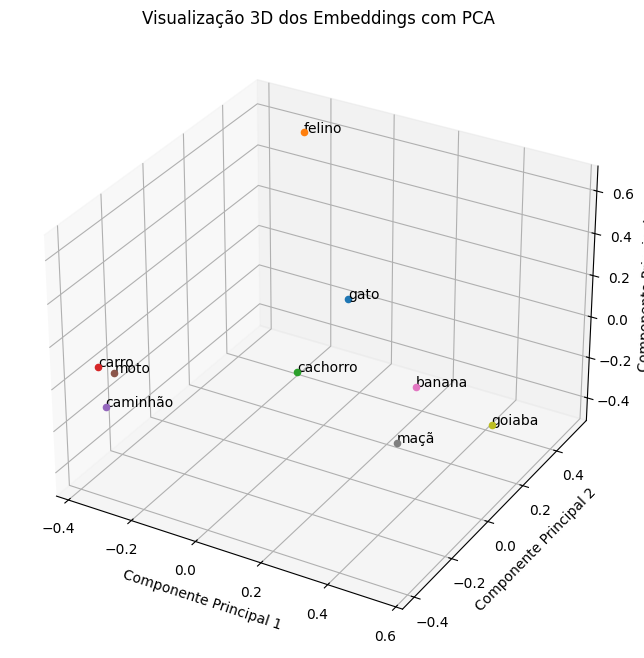

In [54]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

for i, palavra in enumerate(palavras):

    x = embeddings_3d[i, 0]
    y = embeddings_3d[i, 1]
    z = embeddings_3d[i, 2]

    ax.scatter(x, y, z)

    ax.text(
        x,
        y,
        z,
        palavra,
        fontsize=10
    )

ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
ax.set_zlabel("Componente Principal 3")

ax.set_title(
    "Visualização 3D dos Embeddings com PCA"
)

plt.show()

### Visualização dos embeddings em 3D

Para visualizar a distribuição dos embeddings, foi aplicada a técnica PCA
(Principal Component Analysis), reduzindo os vetores originalmente compostos
por 2048 dimensões para três componentes principais.

A representação permite observar a proximidade espacial entre alguns termos
semanticamente relacionados. Palavras associadas a veículos, como "carro",
"moto" e "caminhão", apresentam maior proximidade, enquanto as frutas
"banana", "maçã" e "goiaba" ocupam outra região do espaço.

É importante destacar que a redução de 2048 para apenas três dimensões provoca
perda de informação. Portanto, as distâncias observadas no gráfico não
representam integralmente as relações existentes no espaço original dos
embeddings.